Cell 1 — Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from datasets import load_from_disk
from tqdm import tqdm

Cell 2 — Device and paths

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DATASET_PATH = "D:/plant_disease_data/bd_crop_dataset"
MODEL_SAVE_DIR = "E:/Research/Multi-crop-plant-disease-detection/models"
OUTPUT_DIR = "E:/Research/Multi-crop-plant-disease-detection/outputs"

os.makedirs(os.path.join(OUTPUT_DIR, "gradcam"), exist_ok=True)

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Cell 3 — Load dataset

In [3]:
ds = load_from_disk(DATASET_PATH)
print(ds)

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 86467
    })
    valid: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 24698
    })
    test: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 12423
    })
})


Cell 4 — Class names

In [4]:
train_labels = ds["train"]["label_name"]
class_names = sorted(list(set(train_labels)))
num_classes = len(class_names)

label2id = {name: i for i, name in enumerate(class_names)}
id2label = {i: name for name, i in label2id.items()}

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Number of classes: 94
First 10 classes: ['Banana_Black_Pitting_or_Banana_Rust', 'Banana_Crown_Rot', 'Banana_Healthy', 'Banana_fungal_disease', 'Banana_leaf_Banana_Scab_Moth', 'Banana_leaf_Black_Sigatoka', 'Banana_leaf_Healthy', 'Banana_leaf__Black_Leaf_Streak', 'Banana_leaf__Panama_Disease.', 'Cauliflower_Bacterial_spot_rot']


Cell 5 — Transforms

In [5]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

Cell 6 — Dataset wrapper that keeps original image

In [6]:
class HFDatasetWrapperGradCAM(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item["image"].convert("RGB")
        label_name = item["label_name"]
        label = label2id[label_name]

        original_image = image.copy()

        if self.transform:
            image_tensor = self.transform(image)
        else:
            image_tensor = image

        return image_tensor, label, original_image, label_name

Cell 7 — Test loader

In [7]:
test_dataset_gradcam = HFDatasetWrapperGradCAM(ds["test"], transform=val_test_transform)
test_loader_gradcam = DataLoader(
    test_dataset_gradcam,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test samples:", len(test_dataset_gradcam))

Test samples: 12423


Cell 8 — Build EfficientNetV2-S

In [8]:
def build_efficientnetv2s(num_classes):
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier[1] = torch.nn.Linear(in_features, num_classes)
    return model

Cell 9 — Load trained best model

In [9]:
best_model_path = os.path.join(MODEL_SAVE_DIR, "efficientnetv2s_best.pth")

model = build_efficientnetv2s(num_classes)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)
model.eval()

print("Loaded model from:", best_model_path)

Loaded model from: E:/Research/Multi-crop-plant-disease-detection/models\efficientnetv2s_best.pth


Cell 10 — Find target conv layer

In [10]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [11]:
target_layer = model.features[-1]
print(target_layer)

Conv2dNormActivation(
  (0): Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


Cell 11 — Grad-CAM class

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().numpy()

        cam -= cam.min()
        if cam.max() != 0:
            cam /= cam.max()

        return cam, class_idx

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

Cell 12 — Utility functions

In [13]:
def denormalize_image(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def resize_cam(cam, size=(224, 224)):
    cam_img = Image.fromarray(np.uint8(cam * 255))
    cam_img = cam_img.resize(size, Image.BILINEAR)
    cam = np.array(cam_img) / 255.0
    return cam

def overlay_heatmap(img, cam, alpha=0.4):
    heatmap = plt.get_cmap("jet")(cam)[:, :, :3]
    overlay = (1 - alpha) * img + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)
    return overlay

Cell 13 — Initialize Grad-CAM

In [14]:
gradcam = GradCAM(model, target_layer)

Cell 14 — Visualize one sample by index

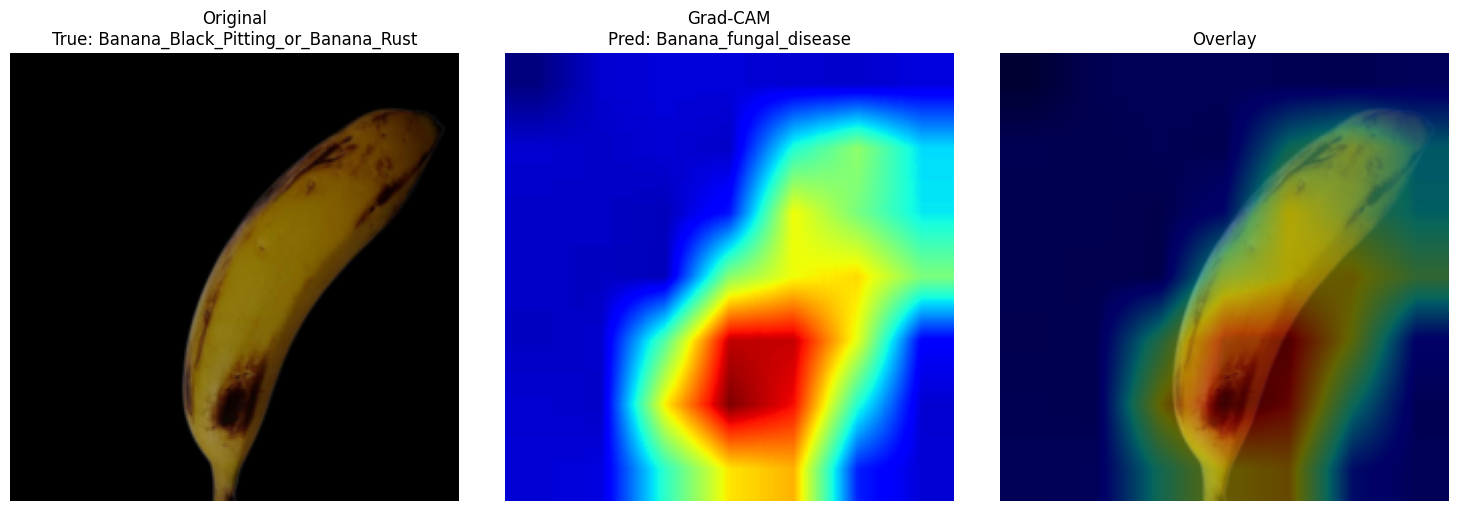

In [15]:
sample_idx = 0

image_tensor, true_label, original_image, true_label_name = test_dataset_gradcam[sample_idx]

input_tensor = image_tensor.unsqueeze(0).to(device)

cam, pred_idx = gradcam.generate(input_tensor)
pred_label_name = id2label[pred_idx]

img_np = denormalize_image(image_tensor)
cam_resized = resize_cam(cam, size=(224, 224))
overlay = overlay_heatmap(img_np, cam_resized)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original\nTrue: {true_label_name}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title(f"Grad-CAM\nPred: {pred_label_name}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Cell 15 — Save Grad-CAM figure

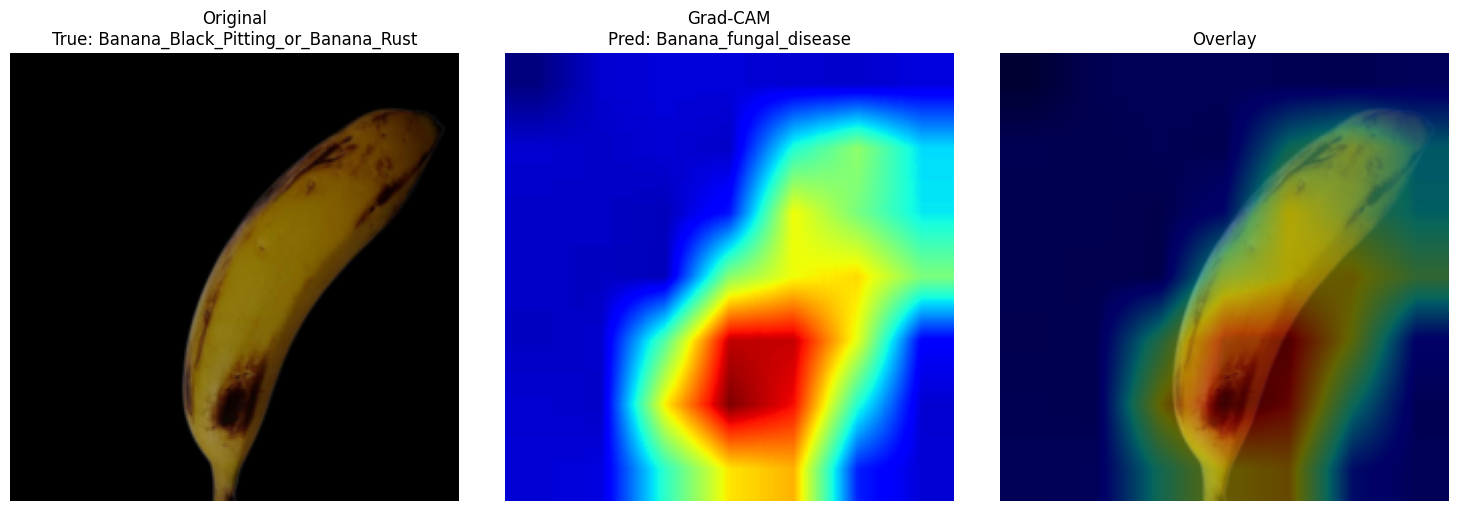

Saved: E:/Research/Multi-crop-plant-disease-detection/outputs\gradcam\gradcam_sample_0.png


In [16]:
save_path = os.path.join(OUTPUT_DIR, "gradcam", f"gradcam_sample_{sample_idx}.png")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original\nTrue: {true_label_name}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title(f"Grad-CAM\nPred: {pred_label_name}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

Cell 16 — Find correctly classified samples

In [17]:
correct_indices = []
wrong_indices = []

with torch.no_grad():
    for idx in tqdm(range(len(test_dataset_gradcam)), desc="Finding predictions"):
        image_tensor, true_label, original_image, true_label_name = test_dataset_gradcam[idx]
        input_tensor = image_tensor.unsqueeze(0).to(device)

        outputs = model(input_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()

        if pred_idx == true_label:
            correct_indices.append(idx)
        else:
            wrong_indices.append(idx)

print("Correct samples:", len(correct_indices))
print("Wrong samples:", len(wrong_indices))

Finding predictions: 100%|██████████| 12423/12423 [12:09<00:00, 17.02it/s]

Correct samples: 11895
Wrong samples: 528


Cell 17 — Show one correct Grad-CAM example

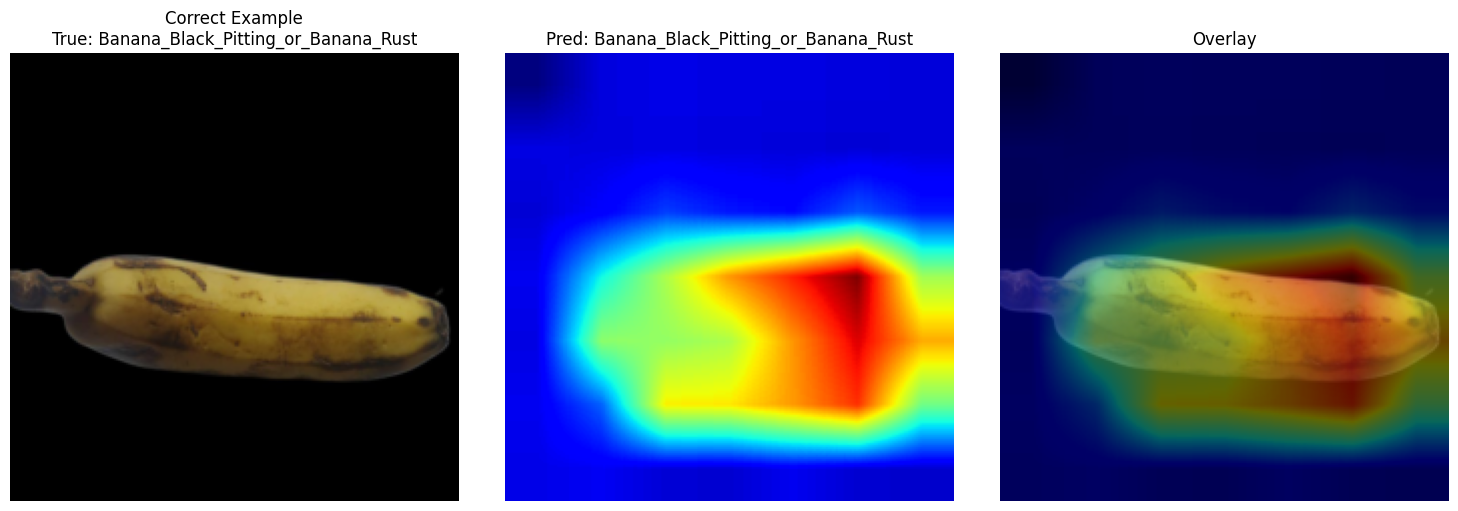

Saved: E:/Research/Multi-crop-plant-disease-detection/outputs\gradcam\correct_example_1.png


In [28]:


sample_idx = correct_indices[0]

image_tensor, true_label, original_image, true_label_name = test_dataset_gradcam[sample_idx]
input_tensor = image_tensor.unsqueeze(0).to(device)

cam, pred_idx = gradcam.generate(input_tensor)
pred_label_name = id2label[pred_idx]

img_np = denormalize_image(image_tensor)
cam_resized = resize_cam(cam, size=(224, 224))
overlay = overlay_heatmap(img_np, cam_resized)

save_path = os.path.join(OUTPUT_DIR, "gradcam", "correct_example_1.png")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Correct Example\nTrue: {true_label_name}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title(f"Pred: {pred_label_name}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

Cell 18 — Show one wrong Grad-CAM example

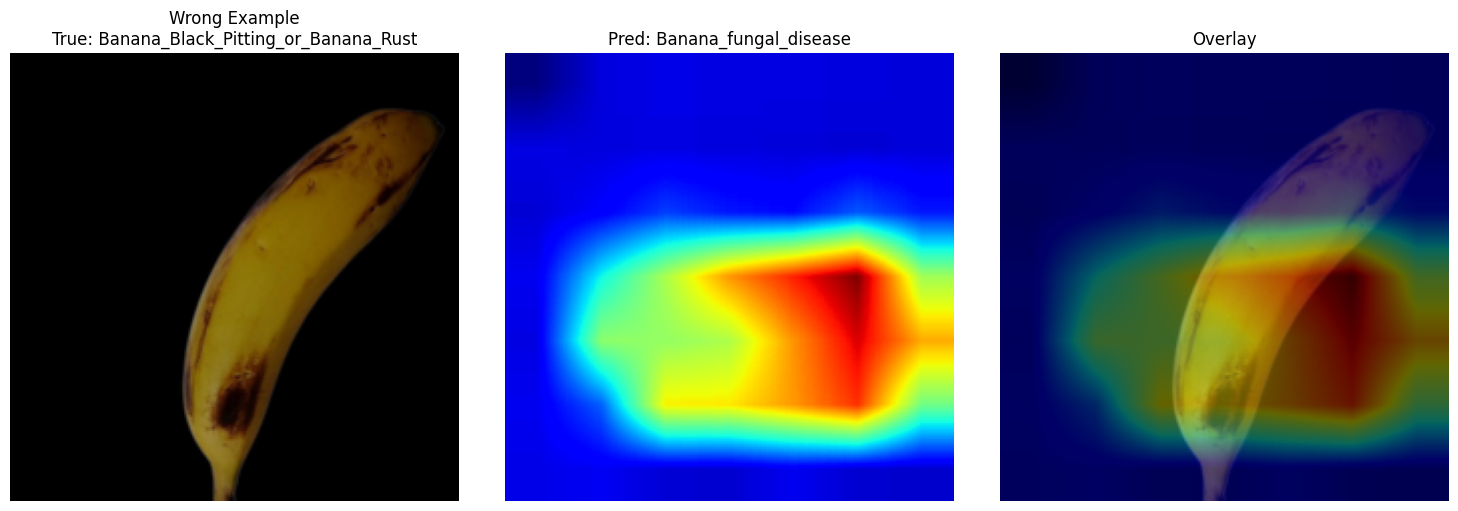

Saved: E:/Research/Multi-crop-plant-disease-detection/outputs\gradcam\wrong_example_1.png


In [27]:


sample_idx = wrong_indices[0]

image_tensor, true_label, original_image, true_label_name = test_dataset_gradcam[sample_idx]
input_tensor = image_tensor.unsqueeze(0).to(device)

cam, pred_idx = gradcam.generate(input_tensor)
pred_label_name = id2label[pred_idx]

img_np = denormalize_image(image_tensor)
cam_resized = resize_cam(cam, size=(224, 224))
overlay = overlay_heatmap(img_np, cam_resized)

save_path = os.path.join(OUTPUT_DIR, "gradcam", "wrong_example_1.png")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Wrong Example\nTrue: {true_label_name}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title(f"Pred: {pred_label_name}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

Cell 19 — Show multiple correct examples

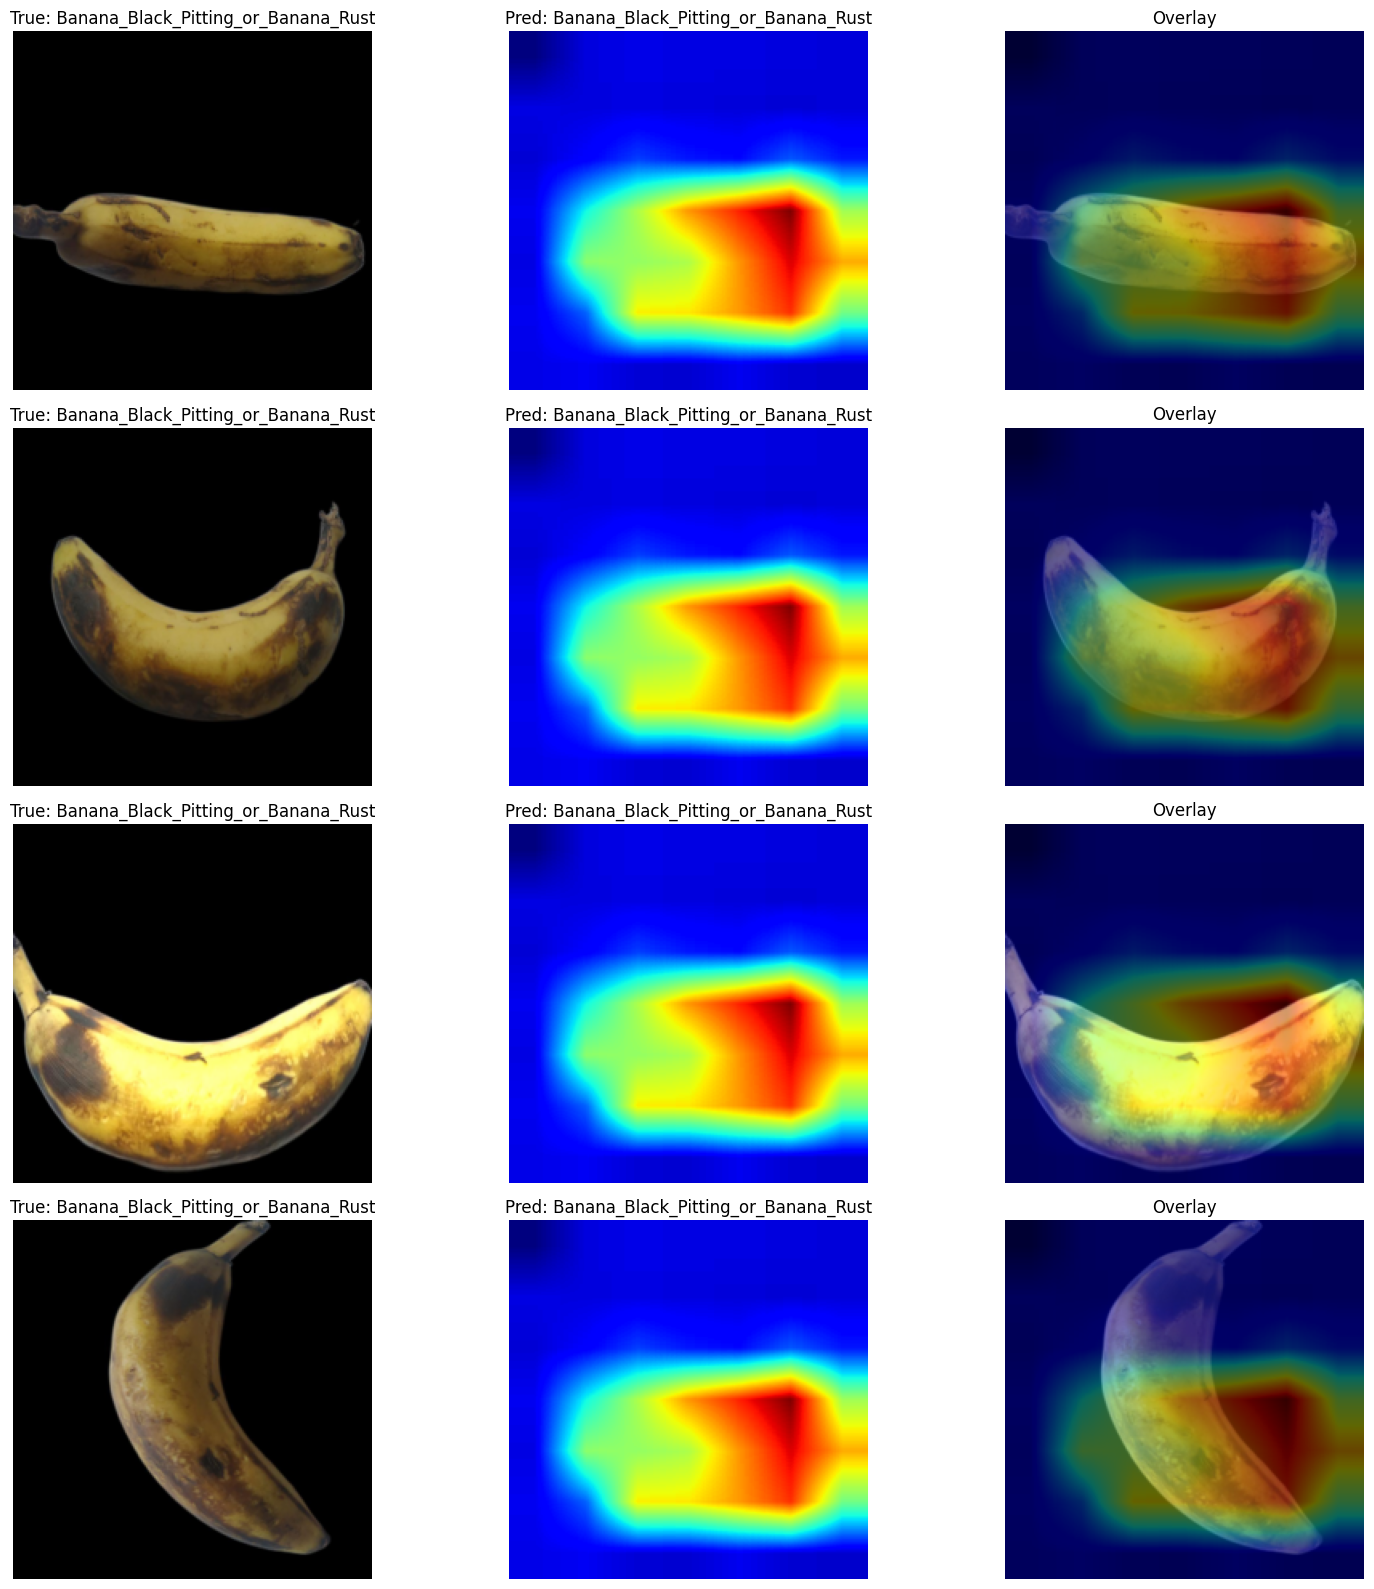

Saved: E:/Research/Multi-crop-plant-disease-detection/outputs\gradcam\correct_examples_4.png


In [25]:


num_examples = min(4, len(correct_indices))
selected_indices = correct_indices[:num_examples]

save_path = os.path.join(OUTPUT_DIR, "gradcam", "correct_examples_4.png")

plt.figure(figsize=(16, 4 * num_examples))

for i, sample_idx in enumerate(selected_indices):
    image_tensor, true_label, original_image, true_label_name = test_dataset_gradcam[sample_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    cam, pred_idx = gradcam.generate(input_tensor)
    pred_label_name = id2label[pred_idx]

    img_np = denormalize_image(image_tensor)
    cam_resized = resize_cam(cam, size=(224, 224))
    overlay = overlay_heatmap(img_np, cam_resized)

    plt.subplot(num_examples, 3, i * 3 + 1)
    plt.imshow(img_np)
    plt.title(f"True: {true_label_name}")
    plt.axis("off")

    plt.subplot(num_examples, 3, i * 3 + 2)
    plt.imshow(cam_resized, cmap="jet")
    plt.title(f"Pred: {pred_label_name}")
    plt.axis("off")

    plt.subplot(num_examples, 3, i * 3 + 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

Cell 20 — Show multiple wrong examples

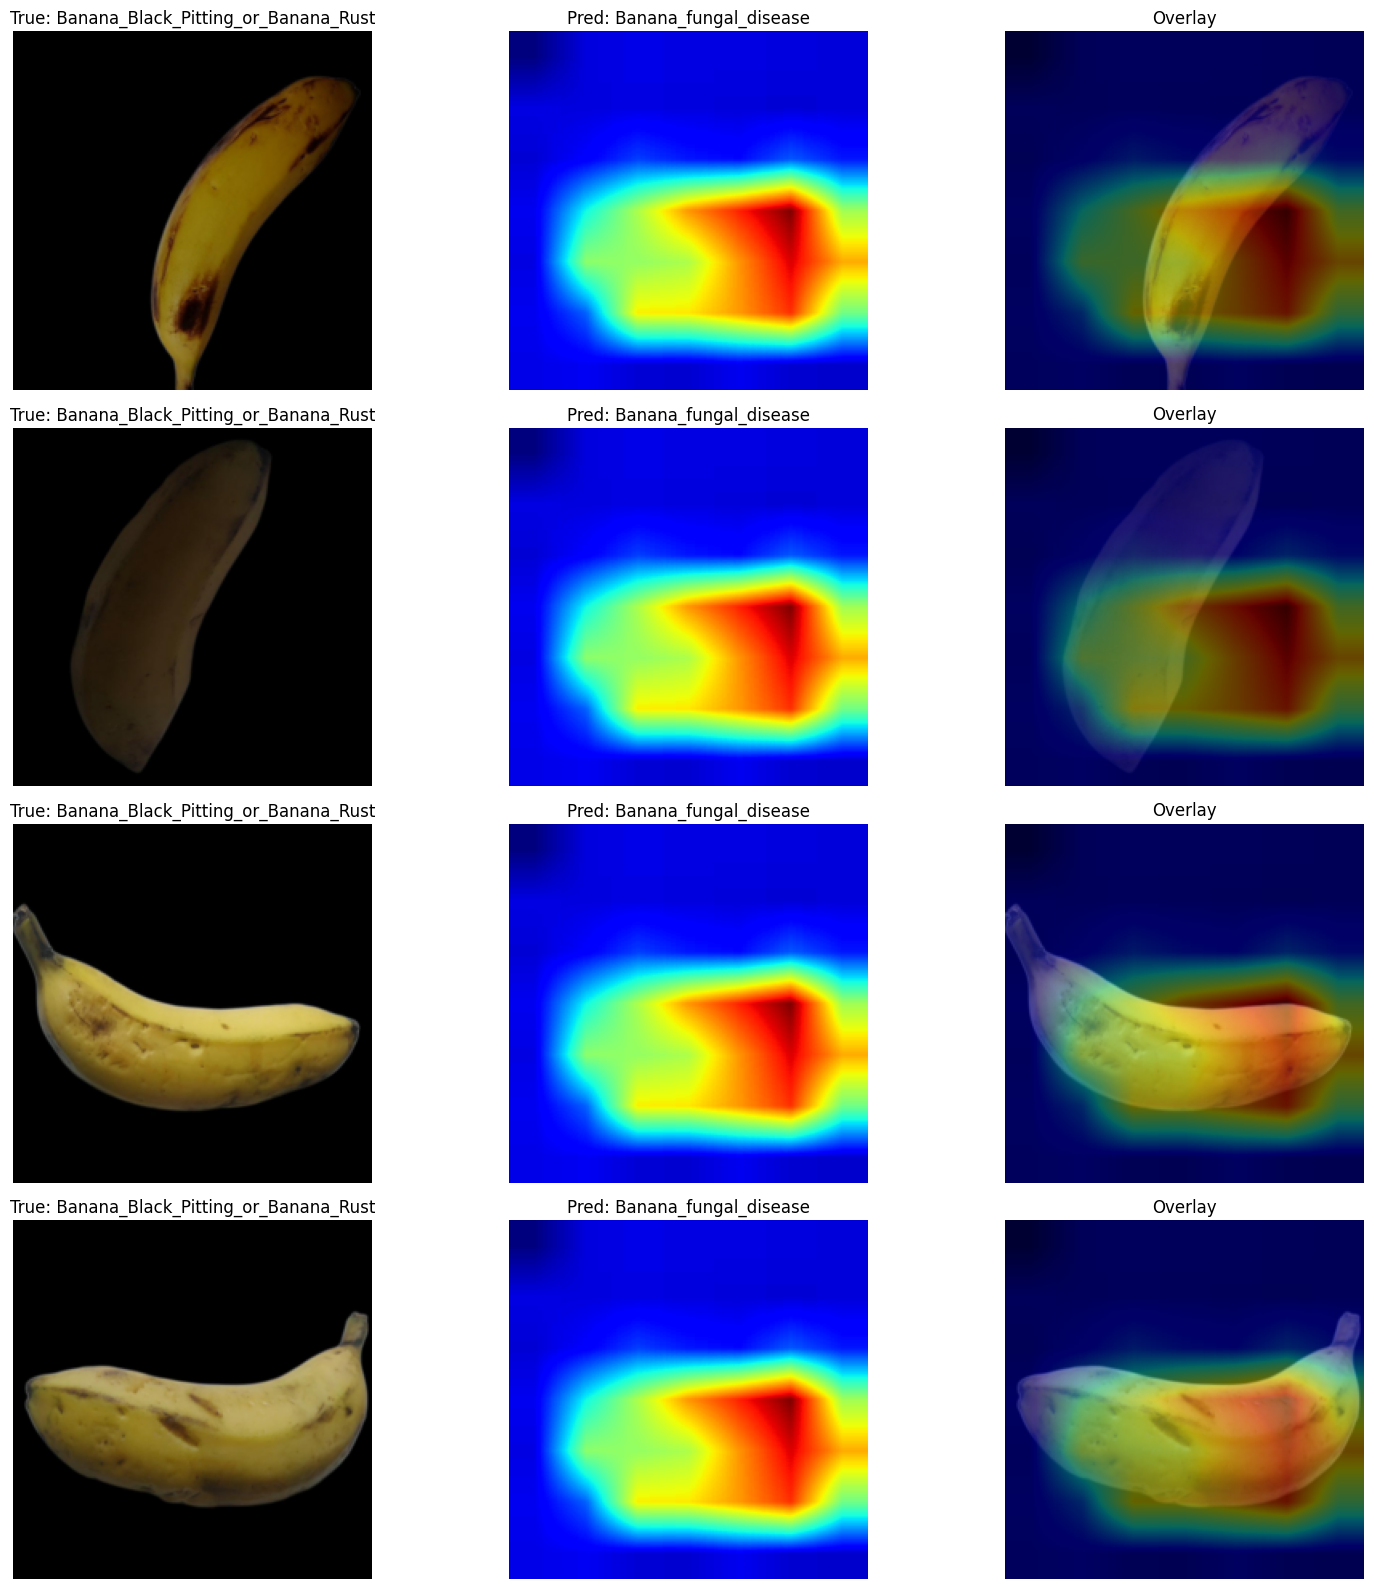

Saved: E:/Research/Multi-crop-plant-disease-detection/outputs\gradcam\wrong_examples_4.png


In [26]:


num_examples = min(4, len(wrong_indices))
selected_indices = wrong_indices[:num_examples]

save_path = os.path.join(OUTPUT_DIR, "gradcam", "wrong_examples_4.png")

plt.figure(figsize=(16, 4 * num_examples))

for i, sample_idx in enumerate(selected_indices):
    image_tensor, true_label, original_image, true_label_name = test_dataset_gradcam[sample_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    cam, pred_idx = gradcam.generate(input_tensor)
    pred_label_name = id2label[pred_idx]

    img_np = denormalize_image(image_tensor)
    cam_resized = resize_cam(cam, size=(224, 224))
    overlay = overlay_heatmap(img_np, cam_resized)

    plt.subplot(num_examples, 3, i * 3 + 1)
    plt.imshow(img_np)
    plt.title(f"True: {true_label_name}")
    plt.axis("off")

    plt.subplot(num_examples, 3, i * 3 + 2)
    plt.imshow(cam_resized, cmap="jet")
    plt.title(f"Pred: {pred_label_name}")
    plt.axis("off")

    plt.subplot(num_examples, 3, i * 3 + 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

Cell 21 — Clean up hooks

In [22]:
gradcam.remove_hooks()
print("Grad-CAM hooks removed.")

Grad-CAM hooks removed.
